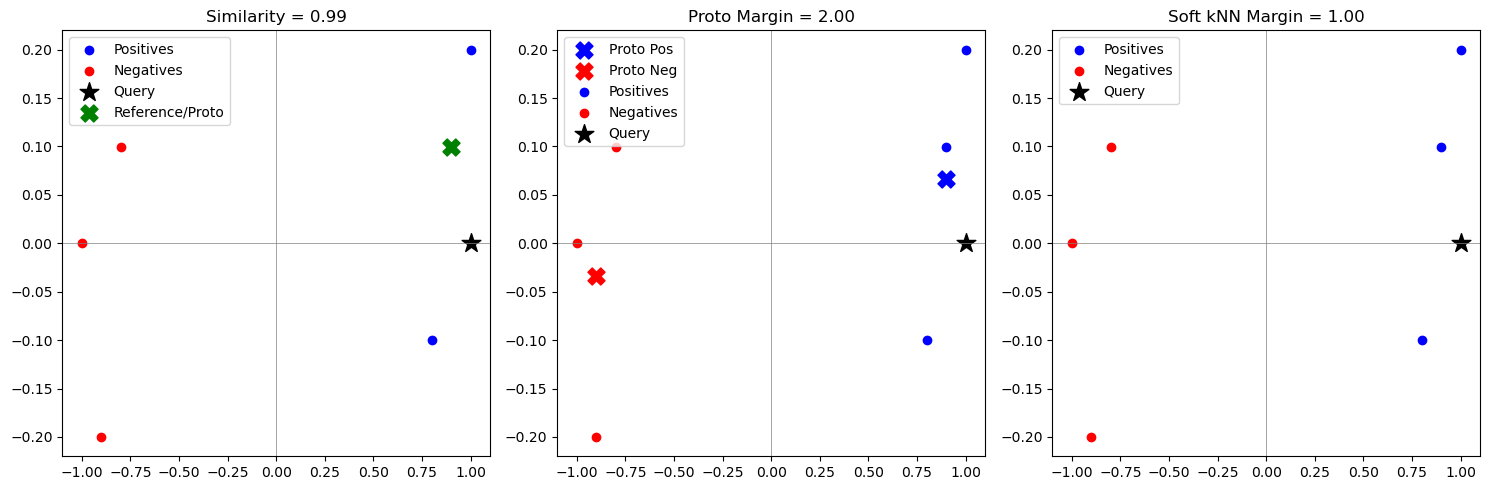

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --- Hilfsfunktionen ---
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

# Generate toy embeddings in 2D
np.random.seed(42)
query = np.array([1.0, 0.0])  # Query embedding
positives = np.array([[0.9, 0.1], [0.8, -0.1], [1.0, 0.2]])  # same class
negatives = np.array([[-0.8, 0.1], [-0.9, -0.2], [-1.0, 0.0]])  # other class

# ---- 1) Similarity Score (query vs. single ref) ----
ref = positives[0]
sim_score = cosine_sim(query, ref)

# ---- 2) Proto Margin (query vs. averaged pos & neg prototypes) ----
proto_pos = positives.mean(axis=0)
proto_neg = negatives.mean(axis=0)
sim_pos = cosine_sim(query, proto_pos)
sim_neg = cosine_sim(query, proto_neg)
proto_margin = sim_pos - sim_neg

# ---- 3) Soft kNN Proxy (weighted prob mass) ----
all_embeddings = np.vstack([positives, negatives])
labels = np.array([1]*len(positives) + [0]*len(negatives))
sims = np.array([cosine_sim(query, e) for e in all_embeddings])
weights = np.exp(sims / 0.1) / np.sum(np.exp(sims / 0.1))  # softmax
prob_friends = np.sum(weights[labels==1])
prob_foes = np.sum(weights[labels==0])
soft_margin = prob_friends - prob_foes

# ---- Plot ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Base plot function
def plot_embeddings(ax, title, highlight=None):
    ax.scatter(positives[:,0], positives[:,1], c='blue', label="Positives")
    ax.scatter(negatives[:,0], negatives[:,1], c='red', label="Negatives")
    ax.scatter(query[0], query[1], c='black', marker='*', s=200, label="Query")
    if highlight is not None:
        ax.scatter(highlight[0], highlight[1], c='green', marker='X', s=150, label="Reference/Proto")
    ax.axhline(0, color='gray', linewidth=0.5)
    ax.axvline(0, color='gray', linewidth=0.5)
    ax.set_title(title)
    ax.legend()

# 1) Similarity
plot_embeddings(axes[0], f"Similarity = {sim_score:.2f}", highlight=ref)

# 2) Proto Margin
axes[1].scatter(proto_pos[0], proto_pos[1], c='blue', marker='X', s=150, label="Proto Pos")
axes[1].scatter(proto_neg[0], proto_neg[1], c='red', marker='X', s=150, label="Proto Neg")
plot_embeddings(axes[1], f"Proto Margin = {proto_margin:.2f}")

# 3) Soft Proxy
plot_embeddings(axes[2], f"Soft kNN Margin = {soft_margin:.2f}")

plt.tight_layout()
plt.show()
